In [1]:
import os
import random
from copy import deepcopy
from datetime import timedelta
from time import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import segmentation_models_pytorch as smp
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

sns.set_theme()

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

(current_device := torch.device("cuda" if torch.cuda.is_available() else "cpu"))

device(type='cpu')

# Первый взгляд на набор данных

In [ ]:
data_path = "data"

train_path = os.path.join(data_path, "train")
train_masks_path = os.path.join(data_path, "train_masks")
test_path = os.path.join(data_path, "test")

full_train_images = sorted(os.listdir(train_path))
test_images = sorted(os.listdir(test_path))

print(
    f"Количество изображений для обучения: {len(full_train_images)}",
    f"Количество тестовых изображений: {len(test_images)}",
    sep="\n"
)

Количество изображений для обучения: 5088
Количество тестовых изображений: 5088


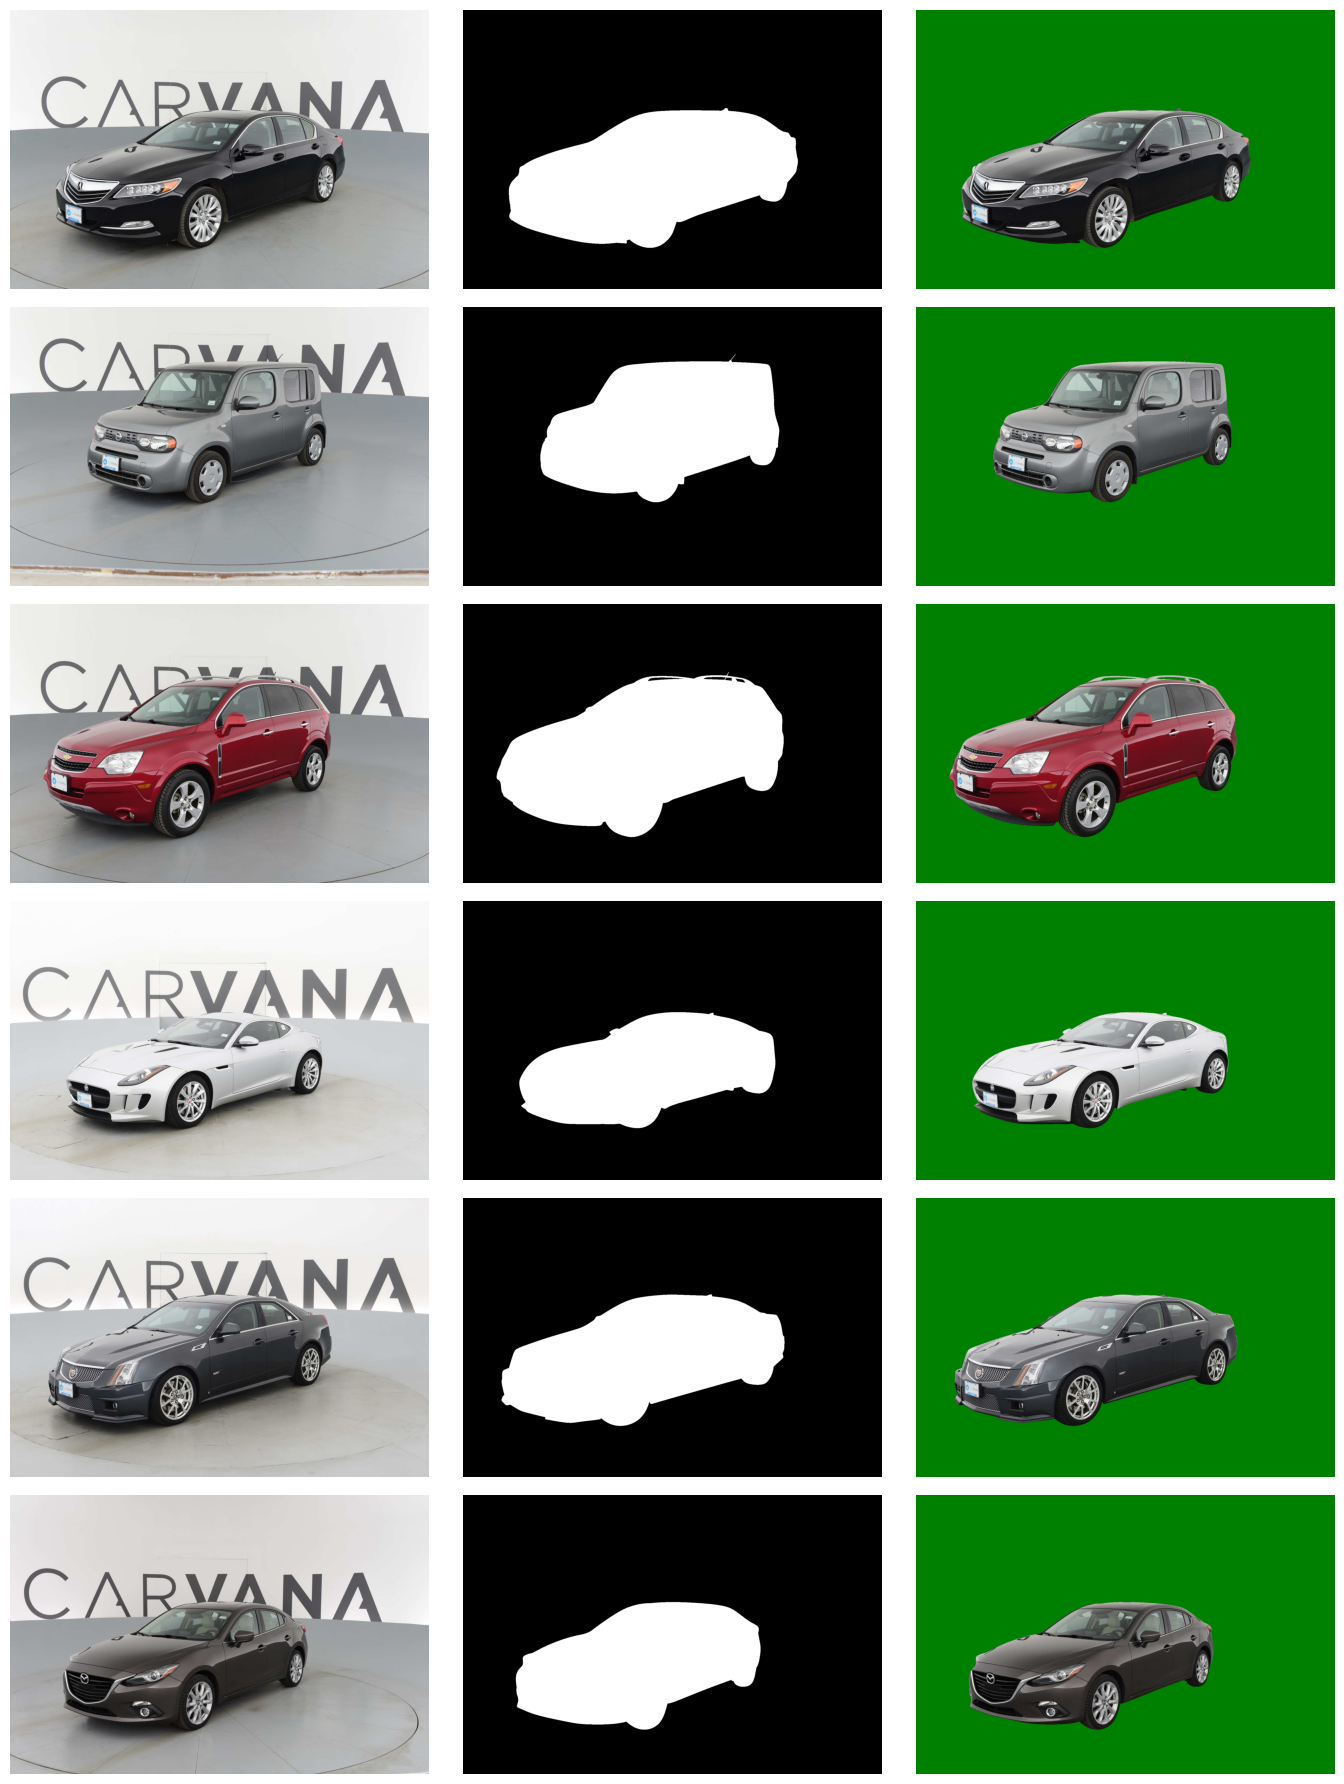

In [ ]:
n_images_per_car = 16
n_samples = 6
sample_indices = list(range(2, n_samples * n_images_per_car + 1, n_images_per_car))
bg_color = np.array([0, 128, 0], dtype=np.uint8)

_, axes = plt.subplots(nrows=n_samples, n_cols=3, figsize=(14, n_samples * 3))

for row, image_index in enumerate(sample_indices):
    img_name = full_train_images[image_index]
    image_path = os.path.join(train_path, img_name)
    mask_path = os.path.join(train_masks_path, img_name.replace('.jpg', '_mask.gif'))

    image = np.array(Image.open(image_path).convert('RGB'))
    mask = Image.open(mask_path).convert("L")
    mask = np.array(mask)
    mask = (mask > 127).astype(np.float32)

    mask_3ch = mask[..., np.newaxis]
    image_green_bg = (image * mask_3ch + bg_color * (1 - mask_3ch)).astype(np.uint8)

    axes[row, 0].imshow(image)
    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 2].imshow(image_green_bg)

    for col in range(3):
        axes[row, col].axis("off")

plt.tight_layout()

# Разбиение на выборки и добавление аугментаций

In [4]:
train_images, valid_images = train_test_split(full_train_images, test_size=0.2, random_state=0)

print(
    f"Размер обучающей выборки: {len(train_images)}",
    f"Размер валидационной выборки: {len(valid_images)}",
    sep="\n"
)

Размер обучающей выборки: 4070
Размер валидационной выборки: 1018


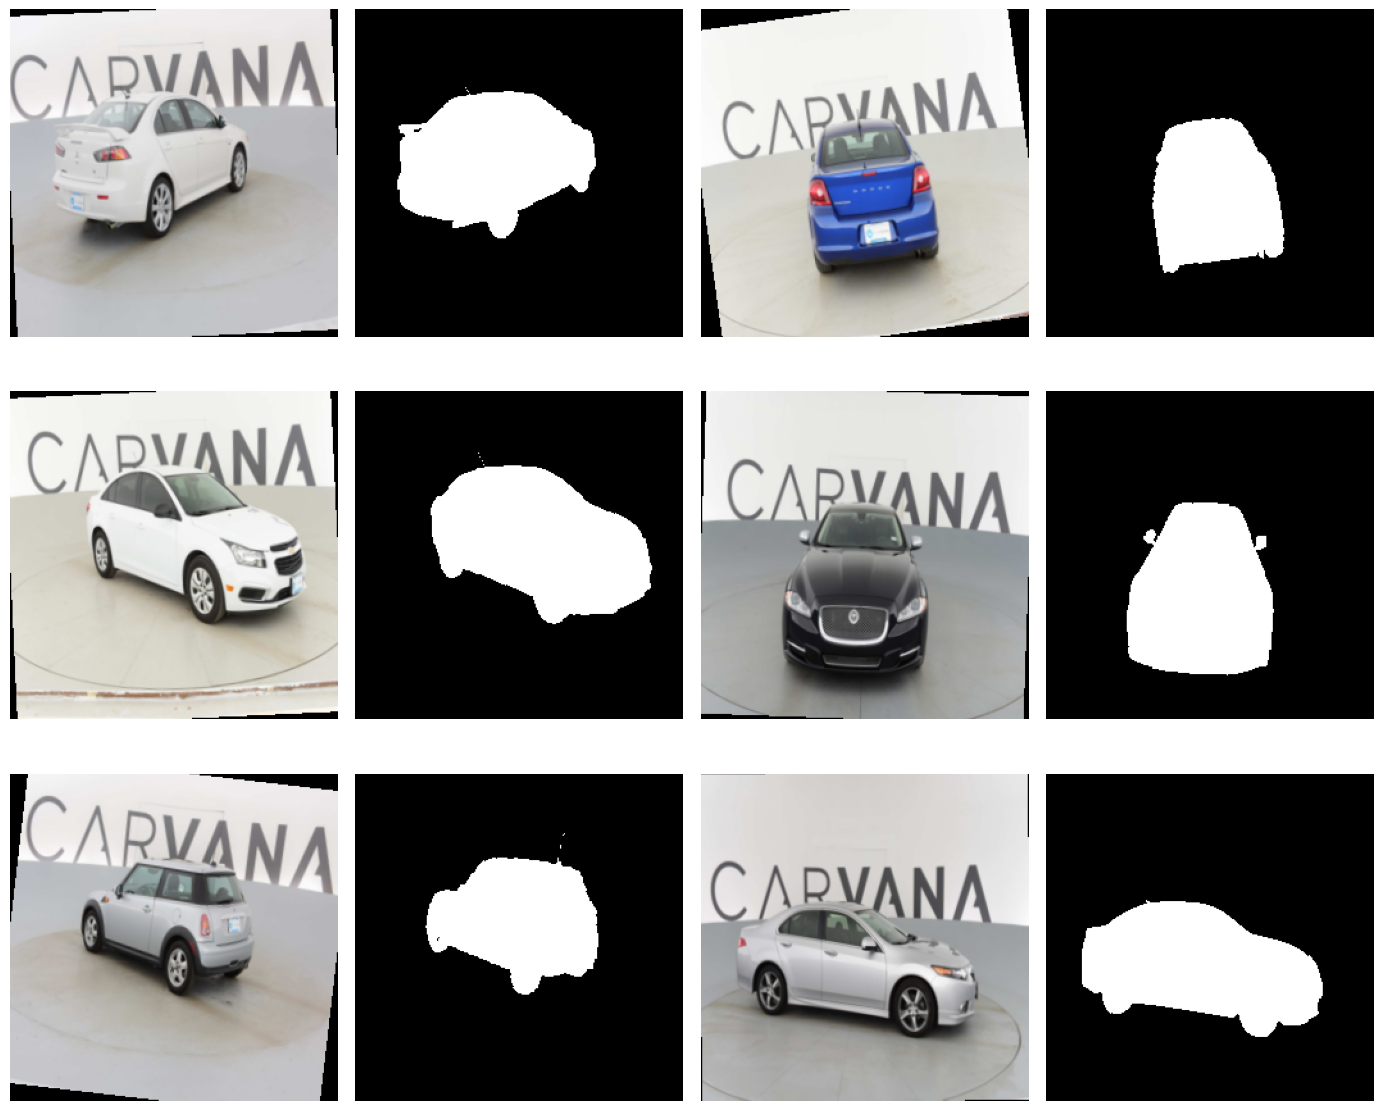

In [ ]:
class CarvanaDataset(Dataset):
    def __init__(self, image_names, images_path, masks_path, image_size, is_aug_needed=False, crop_size=None):
        self.image_names = image_names
        self.images_path = images_path
        self.masks_path = masks_path
        self.image_size = image_size
        self.is_aug_needed = is_aug_needed
        self.crop_size = crop_size

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, image_index):
        image_name = self.image_names[image_index]
        image_path = os.path.join(self.images_path, image_name)
        mask_path = os.path.join(self.masks_path, image_name.replace(".jpg", "_mask.gif"))

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")
        mask = mask.point(lambda p: 1 if p > 127 else 0)

        if self.crop_size:
            i, j, h, w = transforms.RandomCrop.get_params(image, output_size=self.crop_size)
            image = TF.crop(image, i, j, h, w)
            mask = TF.crop(mask, i, j, h, w)
        else:
            image = TF.resize(image, self.image_size, interpolation=TF.InterpolationMode.BILINEAR)
            mask = TF.resize(mask, self.image_size, interpolation=TF.InterpolationMode.NEAREST)

        if self.is_aug_needed:
            if torch.rand(1) > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            angle = torch.empty(1).uniform_(-10, 10).item()
            image = TF.rotate(image, angle, interpolation=TF.InterpolationMode.BILINEAR, fill=(0,))
            mask = TF.rotate(mask, angle, interpolation=TF.InterpolationMode.NEAREST, fill=(0,))

        image = TF.to_tensor(image)
        mask = torch.as_tensor(np.array(mask), dtype=torch.float32).unsqueeze(0)

        return image, mask


image_size = (256, 256)
batch_size = 32

train_dataset = CarvanaDataset(
    image_names=train_images,
    images_path=train_path,
    masks_path=train_masks_path,
    image_size=image_size,
    is_aug_needed=True,
)
train_crops_dataset = CarvanaDataset(
    image_names=train_images,
    images_path=train_path,
    masks_path=train_masks_path,
    image_size=image_size,
    is_aug_needed=False,
    crop_size=image_size,
)
valid_dataset = CarvanaDataset(
    image_names=valid_images,
    images_path=train_path,
    masks_path=train_masks_path,
    image_size=image_size,
    is_aug_needed=False,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
train_crops_loader = DataLoader(train_crops_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)


def show_batch(loader, n_samples=6):
    images, masks = next(iter(loader))

    n_rows = n_samples // 2
    _, axes = plt.subplots(nrows=n_rows, ncols=4, figsize=(14, n_rows * 4))
    if n_rows == 1:
        axes = axes[None, :]

    for i in range(n_samples):
        row = i // 2
        col = (i % 2) * 2

        image_np = images[i].permute(1, 2, 0).cpu().numpy()
        mask_np = masks[i].squeeze().cpu().numpy()

        axes[row, col].imshow(image_np)
        axes[row, col + 1].imshow(mask_np, cmap="gray", vmin=0, vmax=1)
        axes[row, col].axis("off")
        axes[row, col + 1].axis("off")

    plt.tight_layout()


show_batch(train_loader)

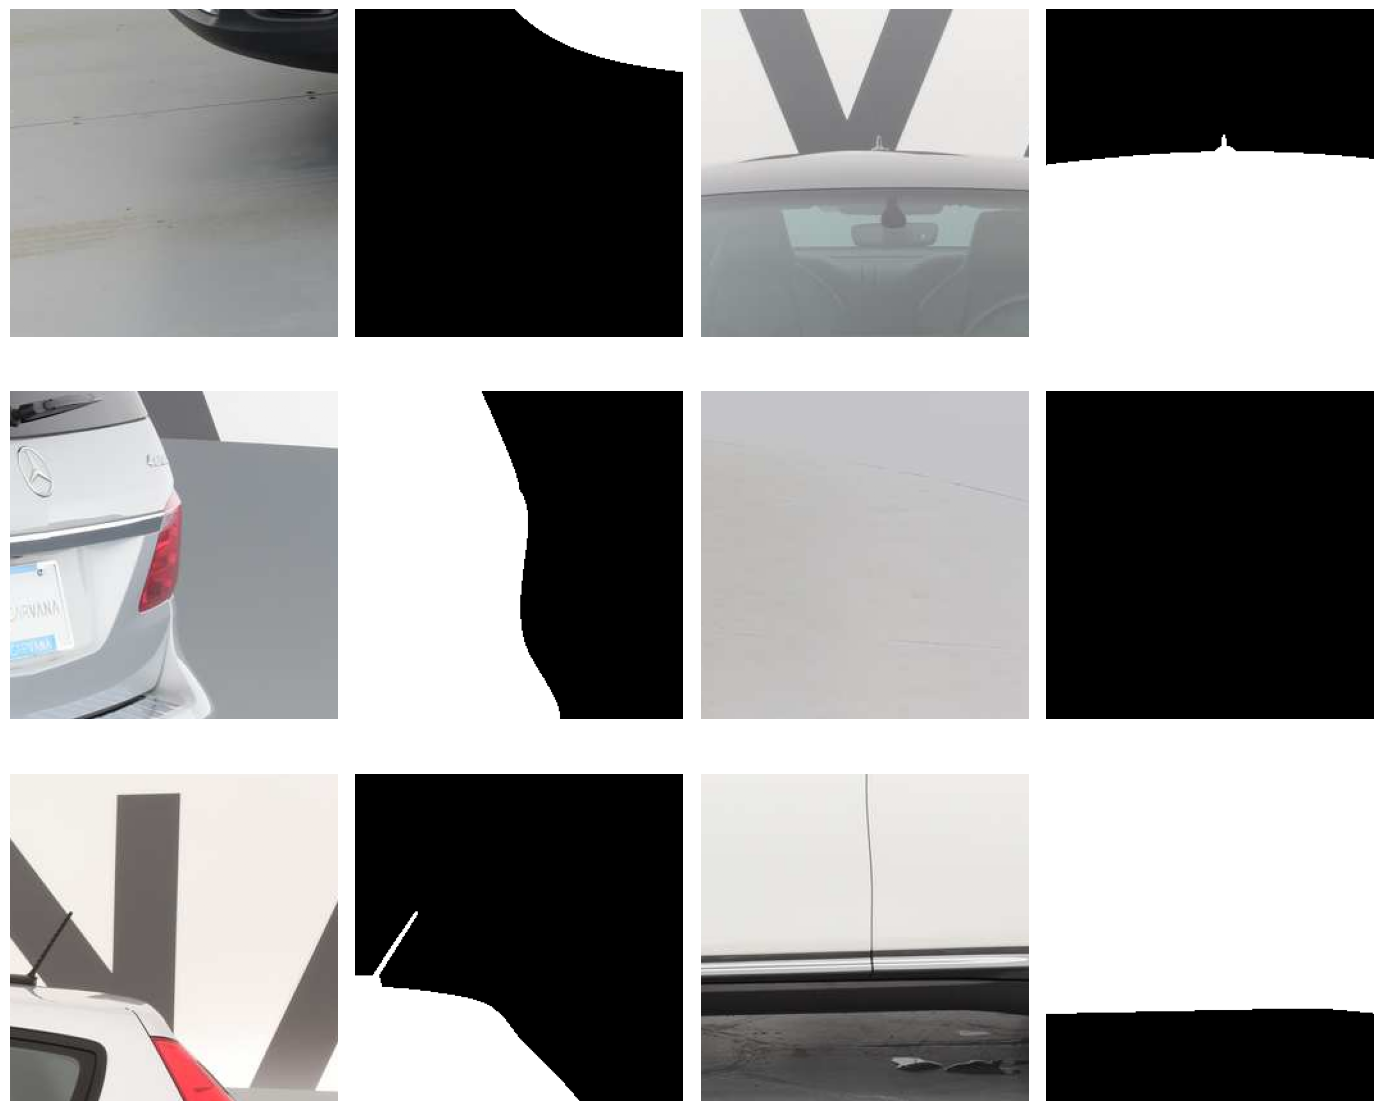

In [6]:
show_batch(train_crops_loader)

# Создание моделей и функций для обучения

In [ ]:
def create_unet(encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, out_channels=1):
    model = smp.Unet(
        encoder_name=encoder_name,
        encoder_weights=encoder_weights,
        in_channels=in_channels,
        classes=out_channels,
        activation=None,
    )
    return model


class SqueezeAndExcitationBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1, groups=in_channels, bias=False),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, groups=out_channels, bias=False),
            nn.Conv2d(out_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            SqueezeAndExcitationBlock(out_channels),
        )

    def forward(self, x):
        return self.block(x)


class DilatedBottleneck(nn.Module):
    def __init__(self, in_channels, out_channels, dilation=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=dilation, dilation=dilation, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNetCustom(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[32, 64, 128, 256]):
        super().__init__()
        self.encoder = nn.ModuleList()
        self.pool = nn.MaxPool2d(2, 2)

        for feature in features:
            self.encoder.append(DoubleConv(in_channels, feature))
            in_channels = feature

        self.bottleneck = DilatedBottleneck(features[-1], features[-1] * 2)

        self.upconvs = nn.ModuleList()
        self.decoders = nn.ModuleList()
        rev_features = list(reversed(features))
        for feature in rev_features:
            self.upconvs.append(nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2))
            self.decoders.append(DoubleConv(feature * 2, feature))

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []
        for down in self.encoder:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for i in range(len(self.upconvs)):
            x = self.upconvs[i](x)
            skip = skip_connections[i]
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)
            x = torch.cat([skip, x], dim=1)
            x = self.decoders[i](x)

        return self.final_conv(x)


class EarlyStopping:
    def __init__(self, patience, min_delta, mode):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_state = None
    
    def __call__(self, current_score, model):
        if self.best_score is None:
            self.best_score = current_score
            self.best_model_state = deepcopy(model.state_dict())

        elif (self.mode == "max" and current_score < self.best_score + self.min_delta) or \
             (self.mode == "min" and current_score > self.best_score - self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        
        else:
            self.best_score = current_score
            self.best_model_state = deepcopy(model.state_dict())
            self.counter = 0


class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        pred = pred.contiguous().view(-1)
        target = target.contiguous().view(-1)

        intersection = (pred * target).sum()
        dice = (2. * intersection + self.smooth) / (pred.sum() + target.sum() + self.smooth)
        return 1 - dice


def get_iou_and_dice(pred_logits, target, threshold=0.5):
    pred = (torch.sigmoid(pred_logits) > threshold).float()
    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    iou = (intersection + 1e-7) / (union + 1e-7)

    dice = (2. * intersection + 1e-7) / (pred.sum() + target.sum() + 1e-7)

    return iou.item(), dice.item()


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()

    running_loss = 0.0
    total_samples = 0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        total_samples += images.size(0)

    epoch_loss = running_loss / total_samples
    
    return epoch_loss


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    total_iou = 0.0
    total_dice = 0.0
    total_samples = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            running_loss += loss.item() * images.size(0)
            iou, dice = get_iou_and_dice(outputs, masks)
            total_iou += iou * images.size(0)
            total_dice += dice * images.size(0)
            total_samples += images.size(0)

    epoch_loss = running_loss / total_samples
    epoch_iou = total_iou / total_samples
    epoch_dice = total_dice / total_samples

    return epoch_loss, epoch_iou, epoch_dice

# Обучение моделей

In [8]:
learning_rate = 0.001
n_epochs = 30

scheduler_mode = "max"
scheduler_factor = 0.5
scheduler_patience = 3

early_stopping_patience = 5
early_stopping_min_delta = 0.001
early_stopping_mode = "max"


def train_model(model, model_name, criterion, train_loader, valid_loader):
    model = model.to(current_device)

    print(f"Обучение модели '{model_name}':")
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer=optimizer,
        mode=scheduler_mode,
        factor=scheduler_factor,
        patience=scheduler_patience,
    )

    early_stopping = EarlyStopping(
        patience=early_stopping_patience,
        min_delta=early_stopping_min_delta,
        mode=early_stopping_mode,
    )
    
    history = {
        "train_loss": [],
        "valid_loss": [],
        "valid_iou": [],
        "valid_dice": [],
    }

    start_time = time()
    
    for epoch in range(n_epochs):
        epoch_start_time = time()

        train_loss = train_epoch(model, train_loader, optimizer, criterion, current_device)
        valid_loss, valid_iou, valid_dice = evaluate(model, valid_loader, criterion, current_device)

        epoch_end_time = time()
        epoch_time = round(epoch_end_time - epoch_start_time)
        
        history["train_loss"].append(train_loss)
        history["valid_loss"].append(valid_loss)
        history["valid_iou"].append(valid_iou)
        history["valid_dice"].append(valid_dice)
        
        print(f"Epoch {epoch + 1:2d}/{n_epochs} ({epoch_time}s) - "
              f"train_loss: {train_loss:.4f} - valid_loss: {valid_loss:.4f} - "
              f"valid_iou: {valid_iou:.4f} - valid_dice: {valid_dice:.4f} - "
              f"lr: {round(optimizer.param_groups[0]["lr"], 6)}")
        
        scheduler.step(valid_dice)
        
        early_stopping(valid_dice, model)
        if early_stopping.early_stop:
            print(f"Ранняя остановка на эпохе {epoch + 1}")
            break
    
    end_time = time()
    elapsed_time = str(timedelta(seconds=round(end_time - start_time)))

    model.load_state_dict(early_stopping.best_model_state)
    best_epoch = len(history["train_loss"]) - early_stopping.counter
    history["best_epoch"] = best_epoch
    print(f"Лучшее значение метрики на валидации: {early_stopping.best_score:.4f} (эпоха {best_epoch})")

    print(f"Время обучения модели '{model_name}': {elapsed_time}")

    torch.save(model.state_dict(), f"./models/{model_name}.pt")

    model.to("cpu")
    torch.cuda.empty_cache()
    
    return history

In [ ]:
model_bce = create_unet().to(current_device)
model_dice = create_unet().to(current_device)
model_custom = UNetCustom().to(current_device)

model_name_bce = "UNetBCE"
model_name_dice = "UNetDice"
model_name_custom = "UNetCustom"

criterion_bce = nn.BCEWithLogitsLoss()
criterion_dice = DiceLoss()

In [ ]:
history_bce = train_model(
    model=model_bce,
    model_name=model_name_bce,
    criterion=criterion_bce,
    train_loader=train_loader,
    valid_loader=valid_loader,
)

Обучение модели 'UNetBCE':
Epoch  1/30 (299s) - train_loss: 0.0678 - valid_loss: 0.0186 - valid_iou: 0.9742 - valid_dice: 0.9869 - lr: 0.001
Epoch  2/30 (208s) - train_loss: 0.0159 - valid_loss: 0.0148 - valid_iou: 0.9743 - valid_dice: 0.9870 - lr: 0.001
Epoch  3/30 (209s) - train_loss: 0.0128 - valid_loss: 0.0107 - valid_iou: 0.9815 - valid_dice: 0.9906 - lr: 0.001
Epoch  4/30 (210s) - train_loss: 0.0113 - valid_loss: 0.0119 - valid_iou: 0.9781 - valid_dice: 0.9889 - lr: 0.001
Epoch  5/30 (210s) - train_loss: 0.0106 - valid_loss: 0.0088 - valid_iou: 0.9839 - valid_dice: 0.9919 - lr: 0.001
Epoch  6/30 (209s) - train_loss: 0.0099 - valid_loss: 0.0086 - valid_iou: 0.9841 - valid_dice: 0.9920 - lr: 0.001
Epoch  7/30 (208s) - train_loss: 0.0094 - valid_loss: 0.0083 - valid_iou: 0.9846 - valid_dice: 0.9923 - lr: 0.001
Epoch  8/30 (210s) - train_loss: 0.0090 - valid_loss: 0.0079 - valid_iou: 0.9853 - valid_dice: 0.9926 - lr: 0.001
Epoch  9/30 (208s) - train_loss: 0.0088 - valid_loss: 0.0082 

In [ ]:
history_dice = train_model(
    model=model_dice,
    model_name=model_name_dice,
    criterion=criterion_dice,
    train_loader=train_loader,
    valid_loader=valid_loader,
)

Обучение модели 'UNetDice':
Epoch  1/30 (214s) - train_loss: 0.1133 - valid_loss: 0.0227 - valid_iou: 0.9751 - valid_dice: 0.9874 - lr: 0.001
Epoch  2/30 (211s) - train_loss: 0.0188 - valid_loss: 0.0145 - valid_iou: 0.9784 - valid_dice: 0.9891 - lr: 0.001
Epoch  3/30 (208s) - train_loss: 0.0138 - valid_loss: 0.0122 - valid_iou: 0.9795 - valid_dice: 0.9896 - lr: 0.001
Epoch  4/30 (213s) - train_loss: 0.0121 - valid_loss: 0.0105 - valid_iou: 0.9817 - valid_dice: 0.9908 - lr: 0.001
Epoch  5/30 (214s) - train_loss: 0.0112 - valid_loss: 0.0119 - valid_iou: 0.9785 - valid_dice: 0.9891 - lr: 0.001
Epoch  6/30 (214s) - train_loss: 0.0107 - valid_loss: 0.0098 - valid_iou: 0.9820 - valid_dice: 0.9909 - lr: 0.001
Epoch  7/30 (212s) - train_loss: 0.0100 - valid_loss: 0.0088 - valid_iou: 0.9836 - valid_dice: 0.9917 - lr: 0.001
Epoch  8/30 (212s) - train_loss: 0.0094 - valid_loss: 0.0085 - valid_iou: 0.9840 - valid_dice: 0.9919 - lr: 0.001
Epoch  9/30 (211s) - train_loss: 0.0093 - valid_loss: 0.0080

In [ ]:
history_custom = train_model(
    model=model_custom,
    model_name=model_name_custom,
    criterion=criterion_dice,
    train_loader=train_crops_loader,
    valid_loader=valid_loader,
)

Обучение модели 'UNetCustom':
Epoch  1/30 (860s) - train_loss: 0.3801 - valid_loss: 0.5894 - valid_iou: 0.2629 - valid_dice: 0.4163 - lr: 0.001
Epoch  2/30 (939s) - train_loss: 0.1425 - valid_loss: 0.4352 - valid_iou: 0.4020 - valid_dice: 0.5728 - lr: 0.001
Epoch  3/30 (861s) - train_loss: 0.0878 - valid_loss: 0.2908 - valid_iou: 0.5533 - valid_dice: 0.7119 - lr: 0.001
Epoch  4/30 (832s) - train_loss: 0.0745 - valid_loss: 0.2980 - valid_iou: 0.5430 - valid_dice: 0.7031 - lr: 0.001
Epoch  5/30 (818s) - train_loss: 0.0587 - valid_loss: 0.2872 - valid_iou: 0.5554 - valid_dice: 0.7138 - lr: 0.001
Epoch  6/30 (888s) - train_loss: 0.0505 - valid_loss: 0.4714 - valid_iou: 0.3594 - valid_dice: 0.5285 - lr: 0.001
Epoch  7/30 (829s) - train_loss: 0.0452 - valid_loss: 0.3994 - valid_iou: 0.4296 - valid_dice: 0.6006 - lr: 0.001
Epoch  8/30 (843s) - train_loss: 0.0404 - valid_loss: 0.4887 - valid_iou: 0.3437 - valid_dice: 0.5113 - lr: 0.001
Epoch  9/30 (894s) - train_loss: 0.0405 - valid_loss: 0.46

In [ ]:
histories = {
    model_name_bce: history_bce,
    model_name_dice: history_dice,
    model_name_custom: history_custom,
}

results_list = []

for model_name, history in histories.items():
    best_epoch = history["best_epoch"]

    results_list.append({
        "model": model_name,
        "stop_epoch": len(history["train_loss"]),
        "best_epoch": best_epoch,
        "train_loss": f"{history["train_loss"][best_epoch - 1]:.4f}",
        "valid_loss": f"{history["valid_loss"][best_epoch - 1]:.4f}",
        "valid_iou": f"{history["valid_iou"][best_epoch - 1]:.4f}",
        "valid_dice": f"{history["valid_dice"][best_epoch - 1]:.4f}",
    })

results_df = pd.DataFrame(results_list)
results_df.style.hide(axis="index")

model,stop_epoch,best_epoch,train_loss,valid_loss,valid_iou,valid_dice
UNetBCE,10,5,0.0106,0.0088,0.9839,0.9919
UNetDice,13,8,0.0094,0.0085,0.9840,0.9919
UNetCustom,10,5,0.0587,0.2872,0.5554,0.7138


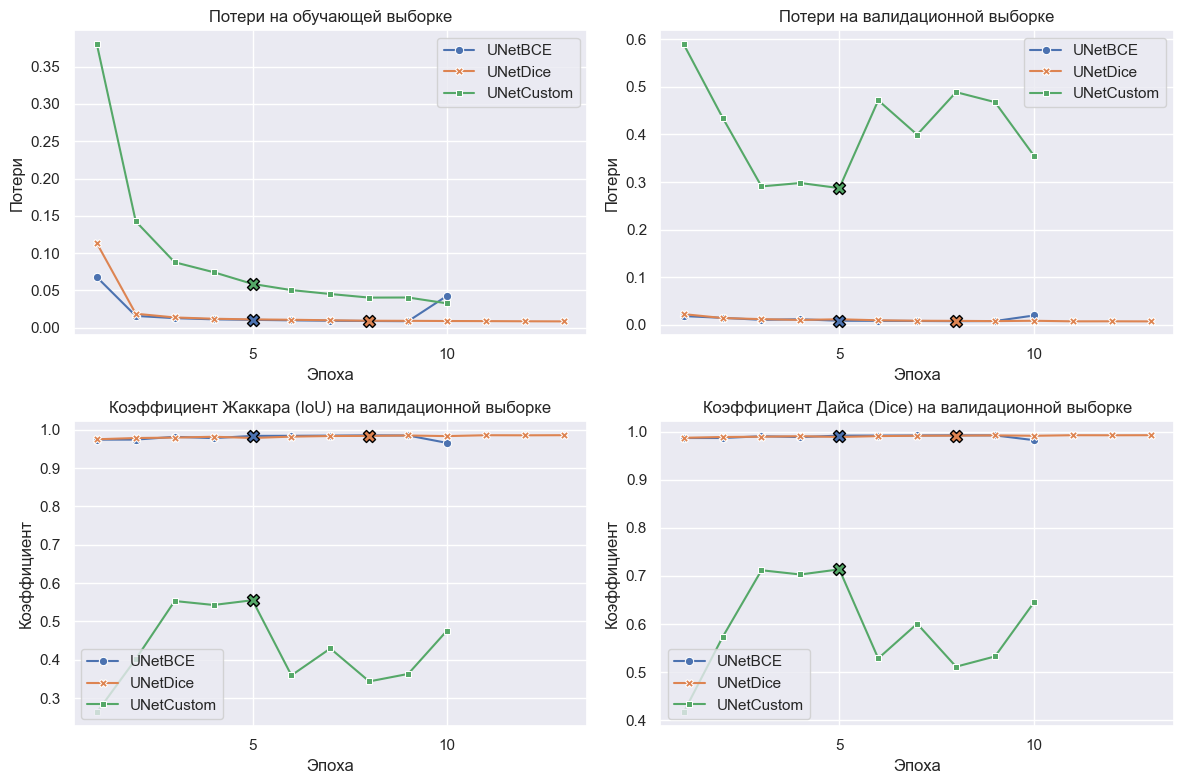

In [14]:
records_list = []
best_epochs = []

for model_name, history in histories.items():
    best_epoch = history["best_epoch"]

    best_epochs.append({
        "model": model_name,
        "best_epoch": best_epoch,
        "train_loss": history["train_loss"][best_epoch - 1],
        "valid_loss": history["valid_loss"][best_epoch - 1],
        "valid_iou": history["valid_iou"][best_epoch - 1],
        "valid_dice": history["valid_dice"][best_epoch - 1],
    })

    for epoch, (train_loss, valid_loss, valid_iou, valid_dice) in enumerate(zip(
        history["train_loss"], history["valid_loss"], history["valid_iou"], history["valid_dice"]
    )):
        records_list.append({
            "model": model_name,
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "valid_loss": valid_loss,
            "valid_iou": valid_iou,
            "valid_dice": valid_dice,
        })

records_df = pd.DataFrame(records_list)

plot_params = {
    "y": ["train_loss", "valid_loss", "valid_iou", "valid_dice"],
    "title": [
        "Потери на обучающей выборке",
        "Потери на валидационной выборке",
        "Коэффициент Жаккара (IoU) на валидационной выборке",
        "Коэффициент Дайса (Dice) на валидационной выборке",
    ],
    "ylabel": ["Потери", "Коэффициент"],
}

n_rows, n_cols = 2, 2
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, 8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    metric = plot_params["y"][i]

    sns.lineplot(
        data=records_df, x="epoch", y=metric, hue="model", style="model", dashes=False, markers=True, ax=ax,
    ).set(
        title=plot_params["title"][i], xlabel="Эпоха", xticks=range(0, 51, 5),
        ylabel=plot_params["ylabel"][i // 2],
    )

    for epoch, color in zip(best_epochs, sns.color_palette(n_colors=len(best_epochs))):
        ax.scatter(
            x=epoch["best_epoch"], y=epoch[metric], s=75,
            color=color, marker="X", edgecolor="black", zorder=5,
        )

    ax.legend(title="", loc="upper right" if i < 2 else "lower left")

plt.tight_layout()

# Тестирование и оценка качества моделей

In [ ]:
model_bce.load_state_dict(
    torch.load(f"./models/{model_name_bce}.pt", map_location=current_device)
)
model_dice.load_state_dict(
    torch.load(f"./models/{model_name_dice}.pt", map_location=current_device)
)
model_custom.load_state_dict(
    torch.load(f"./models/{model_name_custom}.pt", map_location=current_device)
)

<All keys matched successfully>

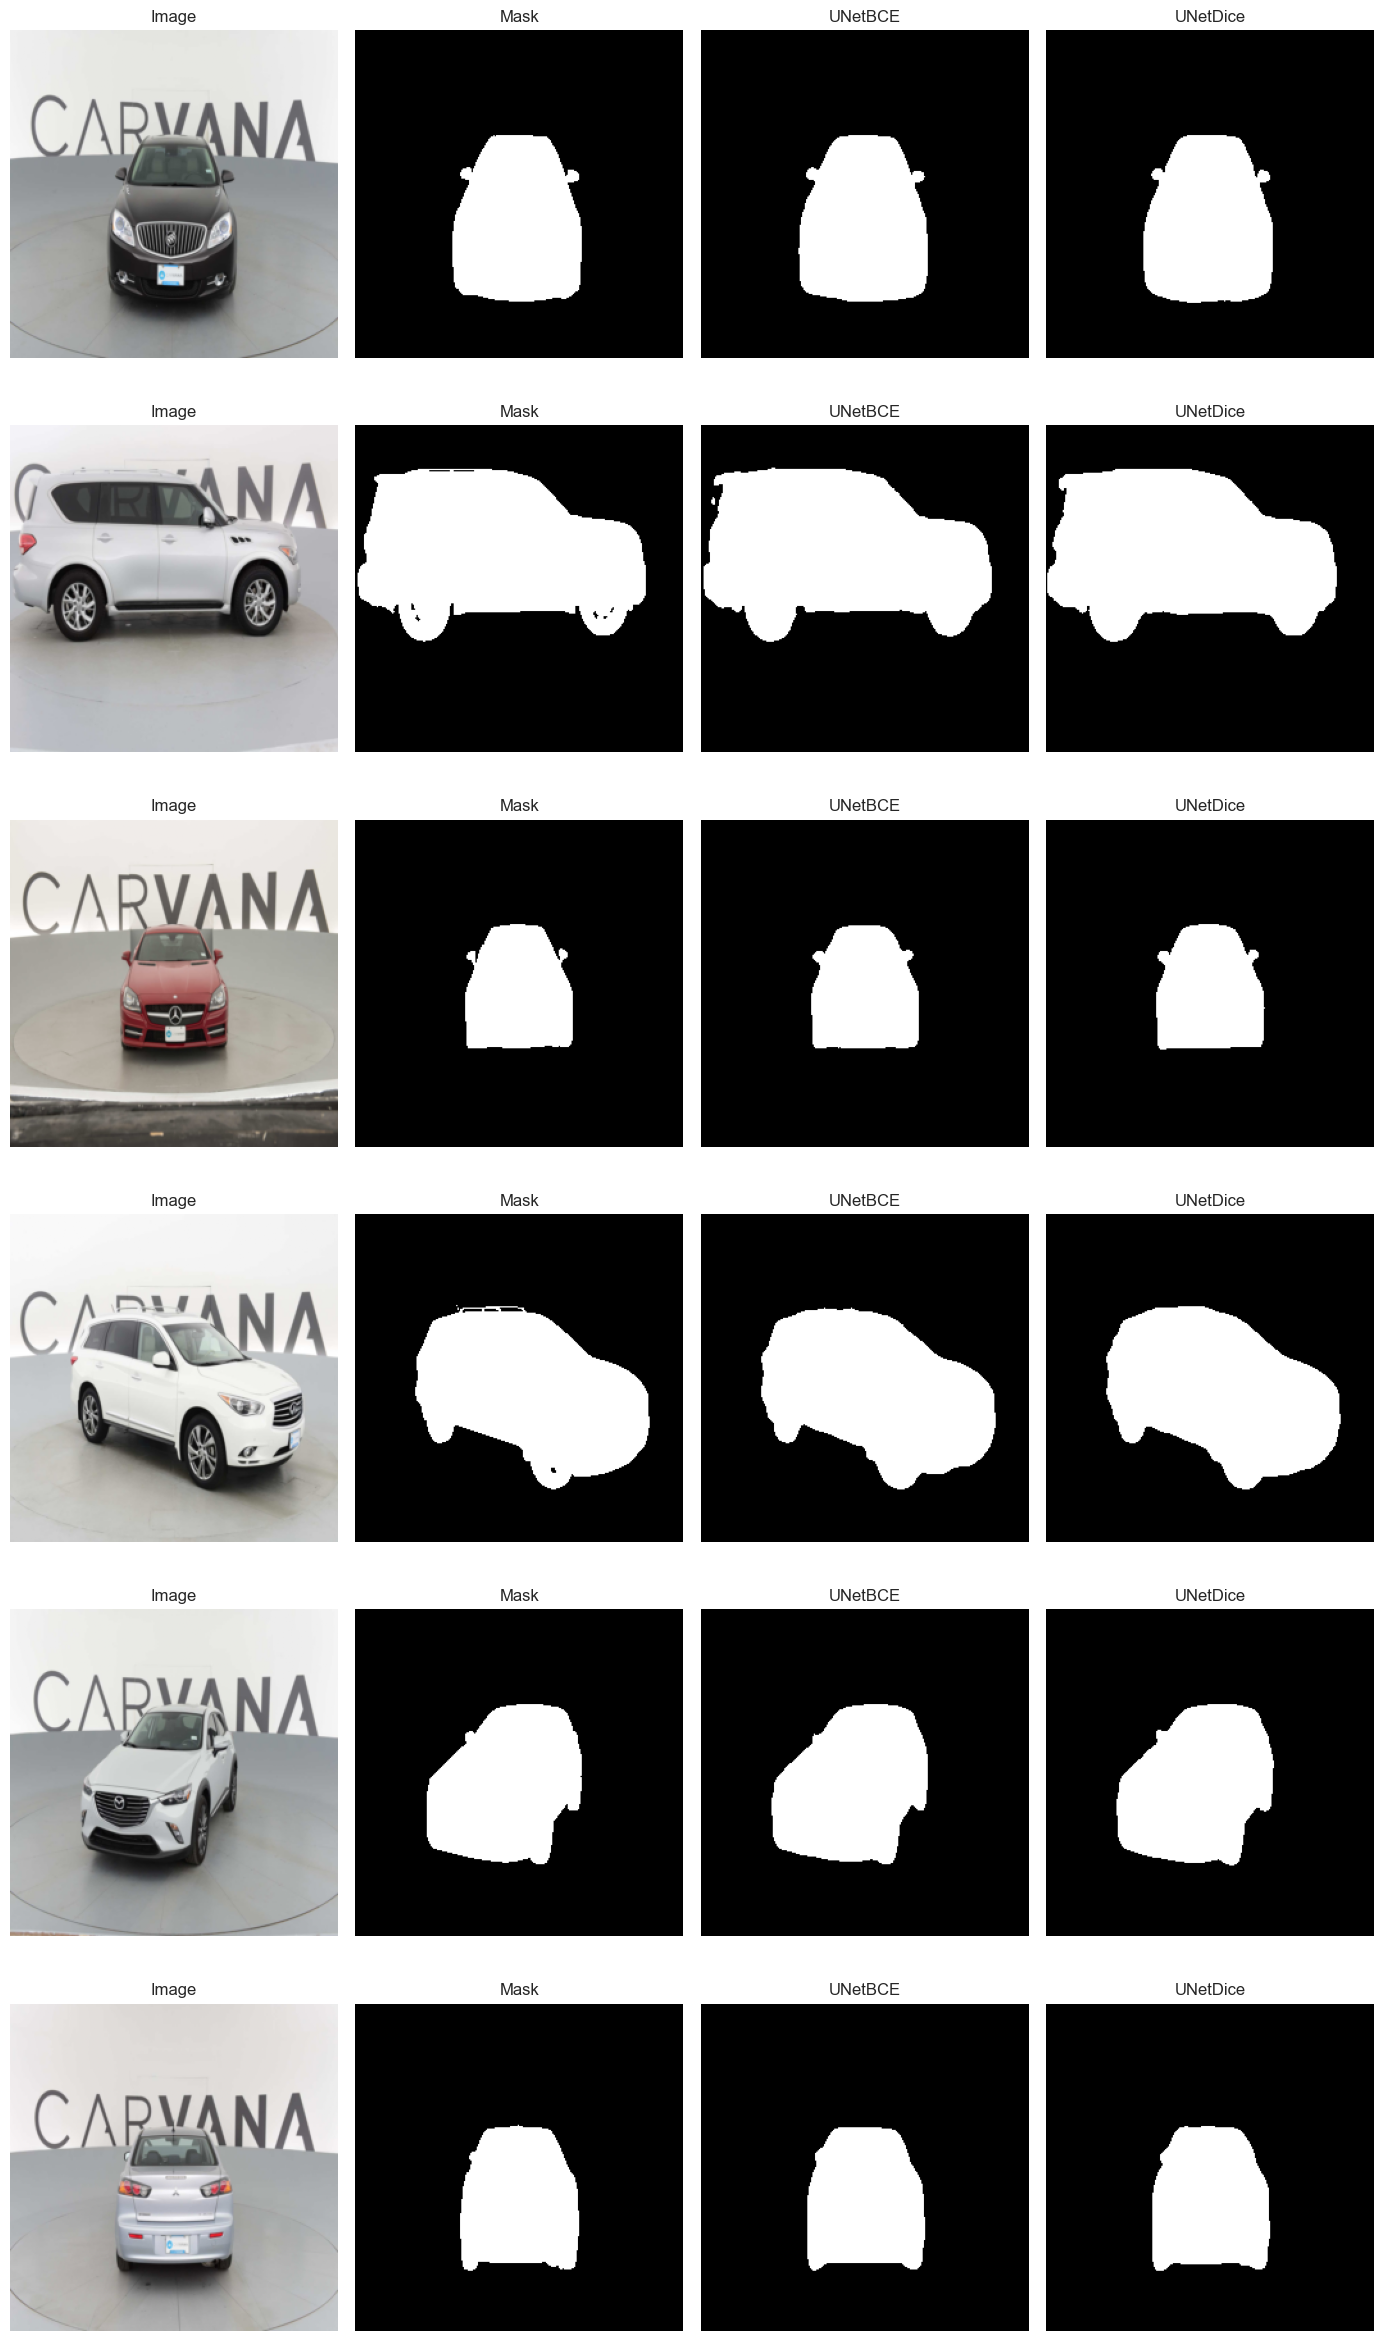

In [ ]:
def show_predictions_double(model1, model2, model1_name, model2_name, loader, n_samples=6):
    model1.eval()
    model2.eval()

    images, masks = next(iter(loader))
    images = images[:n_samples]
    masks = masks[:n_samples]

    with torch.no_grad():
        preds1 = torch.sigmoid(model1(images))
        preds1 = (preds1 > 0.5).float()
        preds2 = torch.sigmoid(model2(images))
        preds2 = (preds2 > 0.5).float()

    images = images.cpu()
    masks = masks.cpu()
    preds1 = preds1.cpu()
    preds2 = preds2.cpu()

    _, axes = plt.subplots(nrows=n_samples, ncols=4, figsize=(14, n_samples * 4))
    if n_samples == 1:
        axes = axes[None, :]

    for i in range(n_samples):
        axes[i, 0].imshow(images[i].permute(1, 2, 0).numpy())
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(masks[i].squeeze(), cmap="gray")
        axes[i, 1].set_title("Mask")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(preds1[i].squeeze(), cmap="gray")
        axes[i, 2].set_title(model1_name)
        axes[i, 2].axis("off")

        axes[i, 3].imshow(preds2[i].squeeze(), cmap="gray")
        axes[i, 3].set_title(model2_name)
        axes[i, 3].axis("off")

    plt.tight_layout()


show_predictions_double(model_bce, model_dice, model_name_bce, model_name_dice, valid_loader)

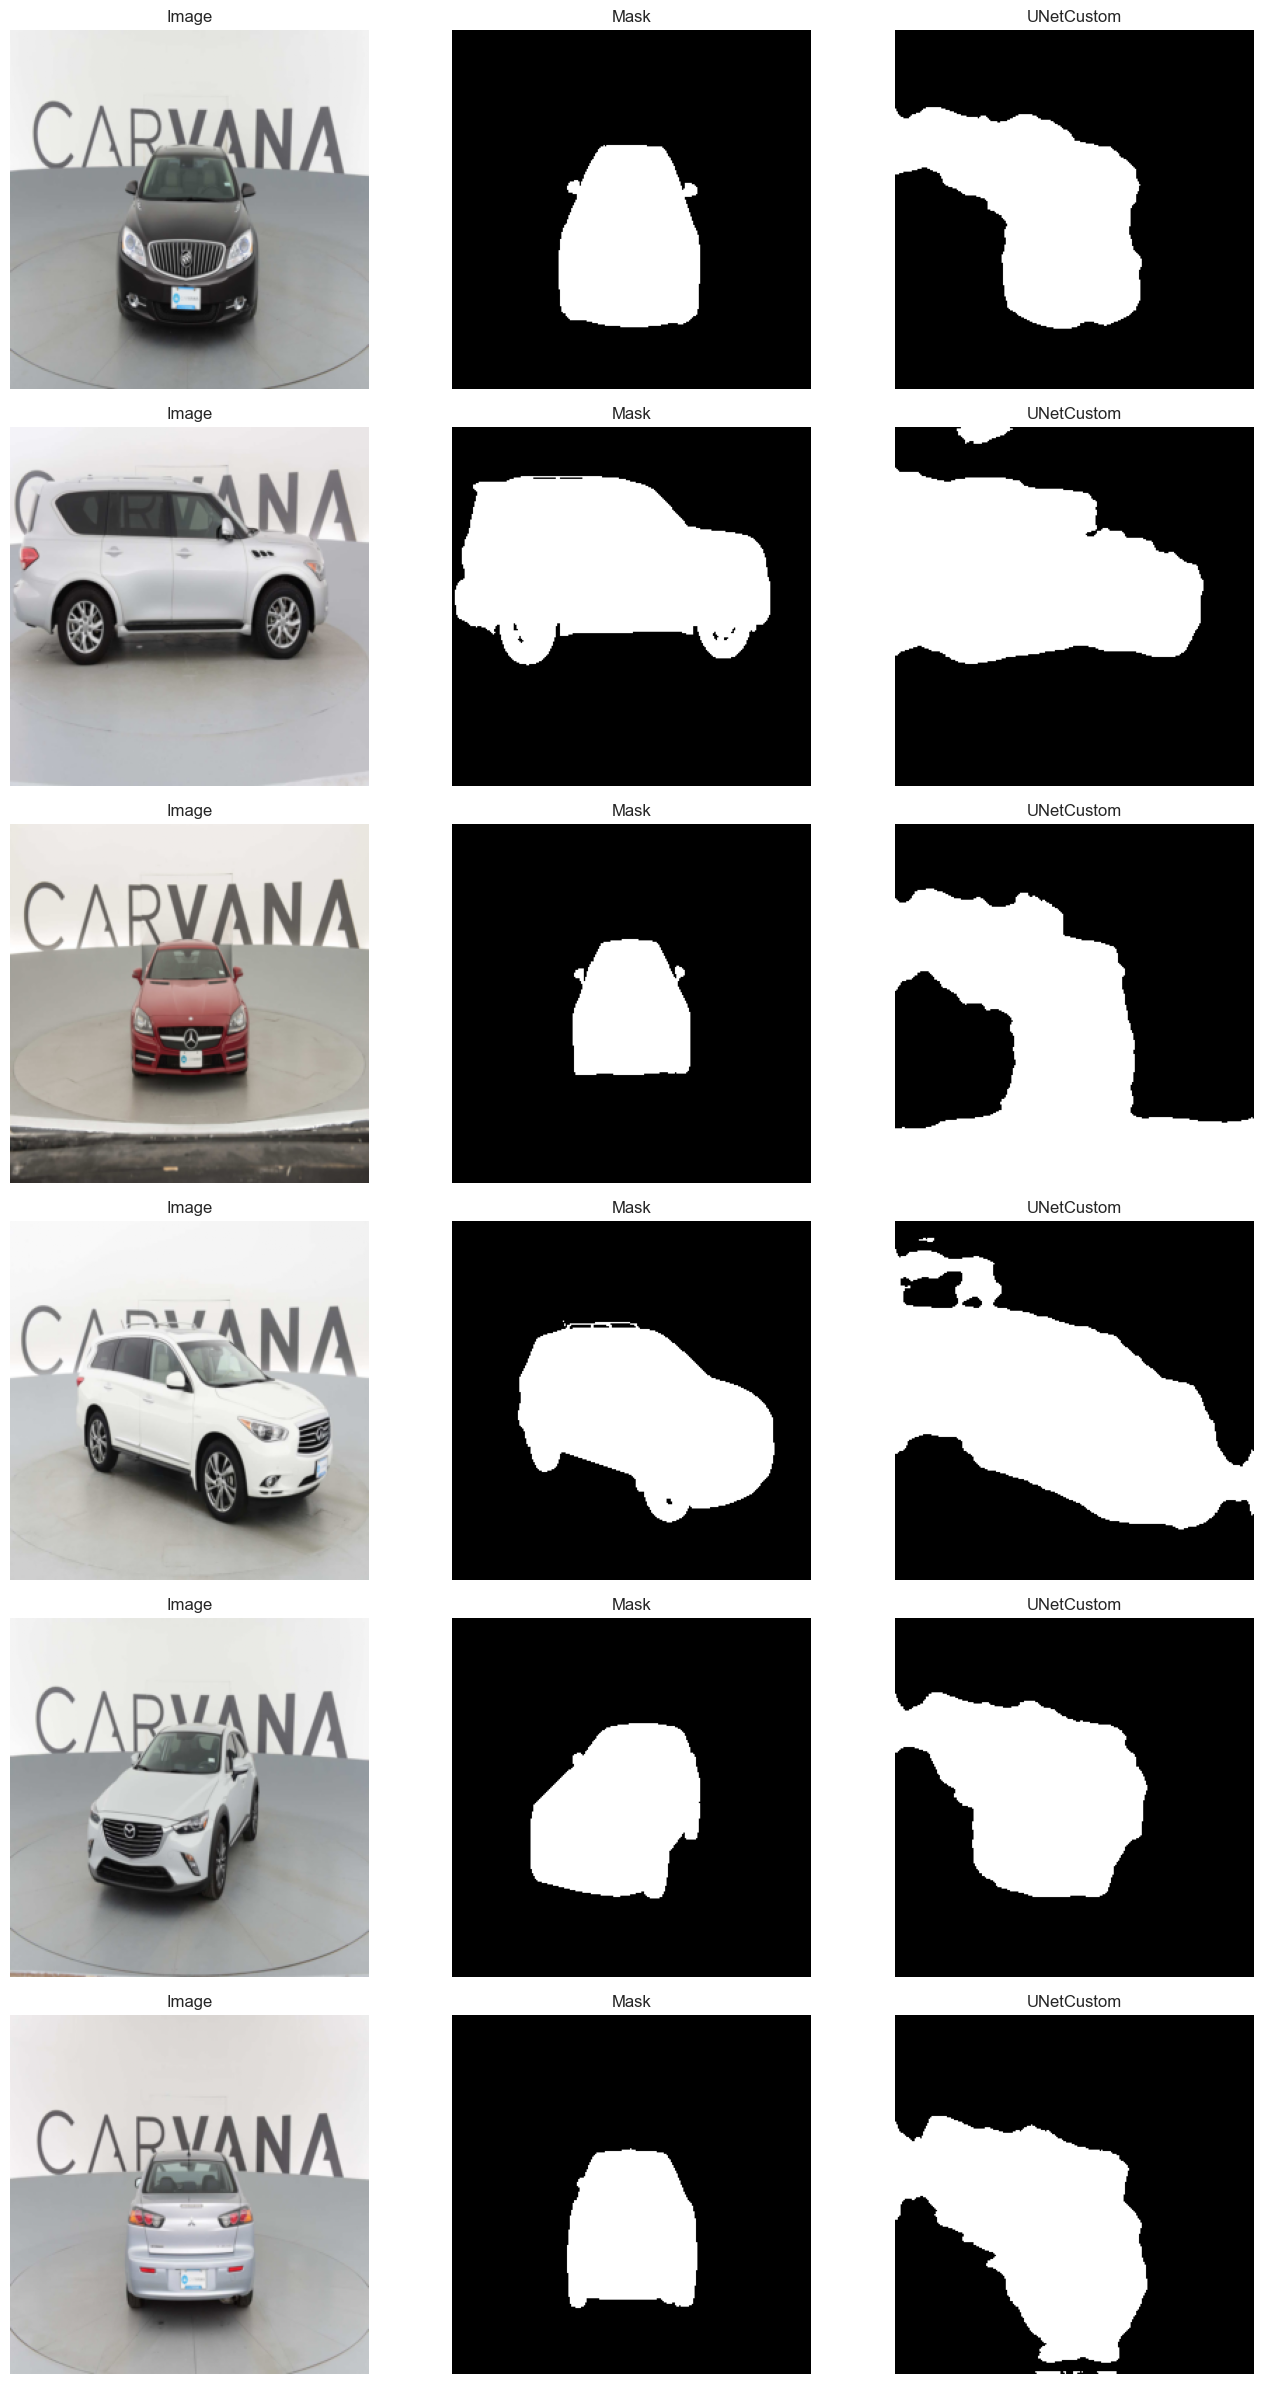

In [ ]:
def show_predictions_single(model, model_name, loader, n_samples=6):
    model.eval()

    images, masks = next(iter(loader))
    images = images[:n_samples]
    masks = masks[:n_samples]

    with torch.no_grad():
        preds = torch.sigmoid(model(images))
        preds = (preds > 0.5).float()

    images = images.cpu()
    masks = masks.cpu()
    preds = preds.cpu()

    _, axes = plt.subplots(nrows=n_samples, ncols=3, figsize=(14, n_samples * 4))
    if n_samples == 1:
        axes = axes[None, :]

    for i in range(n_samples):
        axes[i, 0].imshow(images[i].permute(1, 2, 0).numpy())
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(masks[i].squeeze(), cmap="gray")
        axes[i, 1].set_title("Mask")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(preds[i].squeeze(), cmap="gray")
        axes[i, 2].set_title(model_name)
        axes[i, 2].axis("off")

    plt.tight_layout()


show_predictions_single(model_custom, model_name_custom, valid_loader)

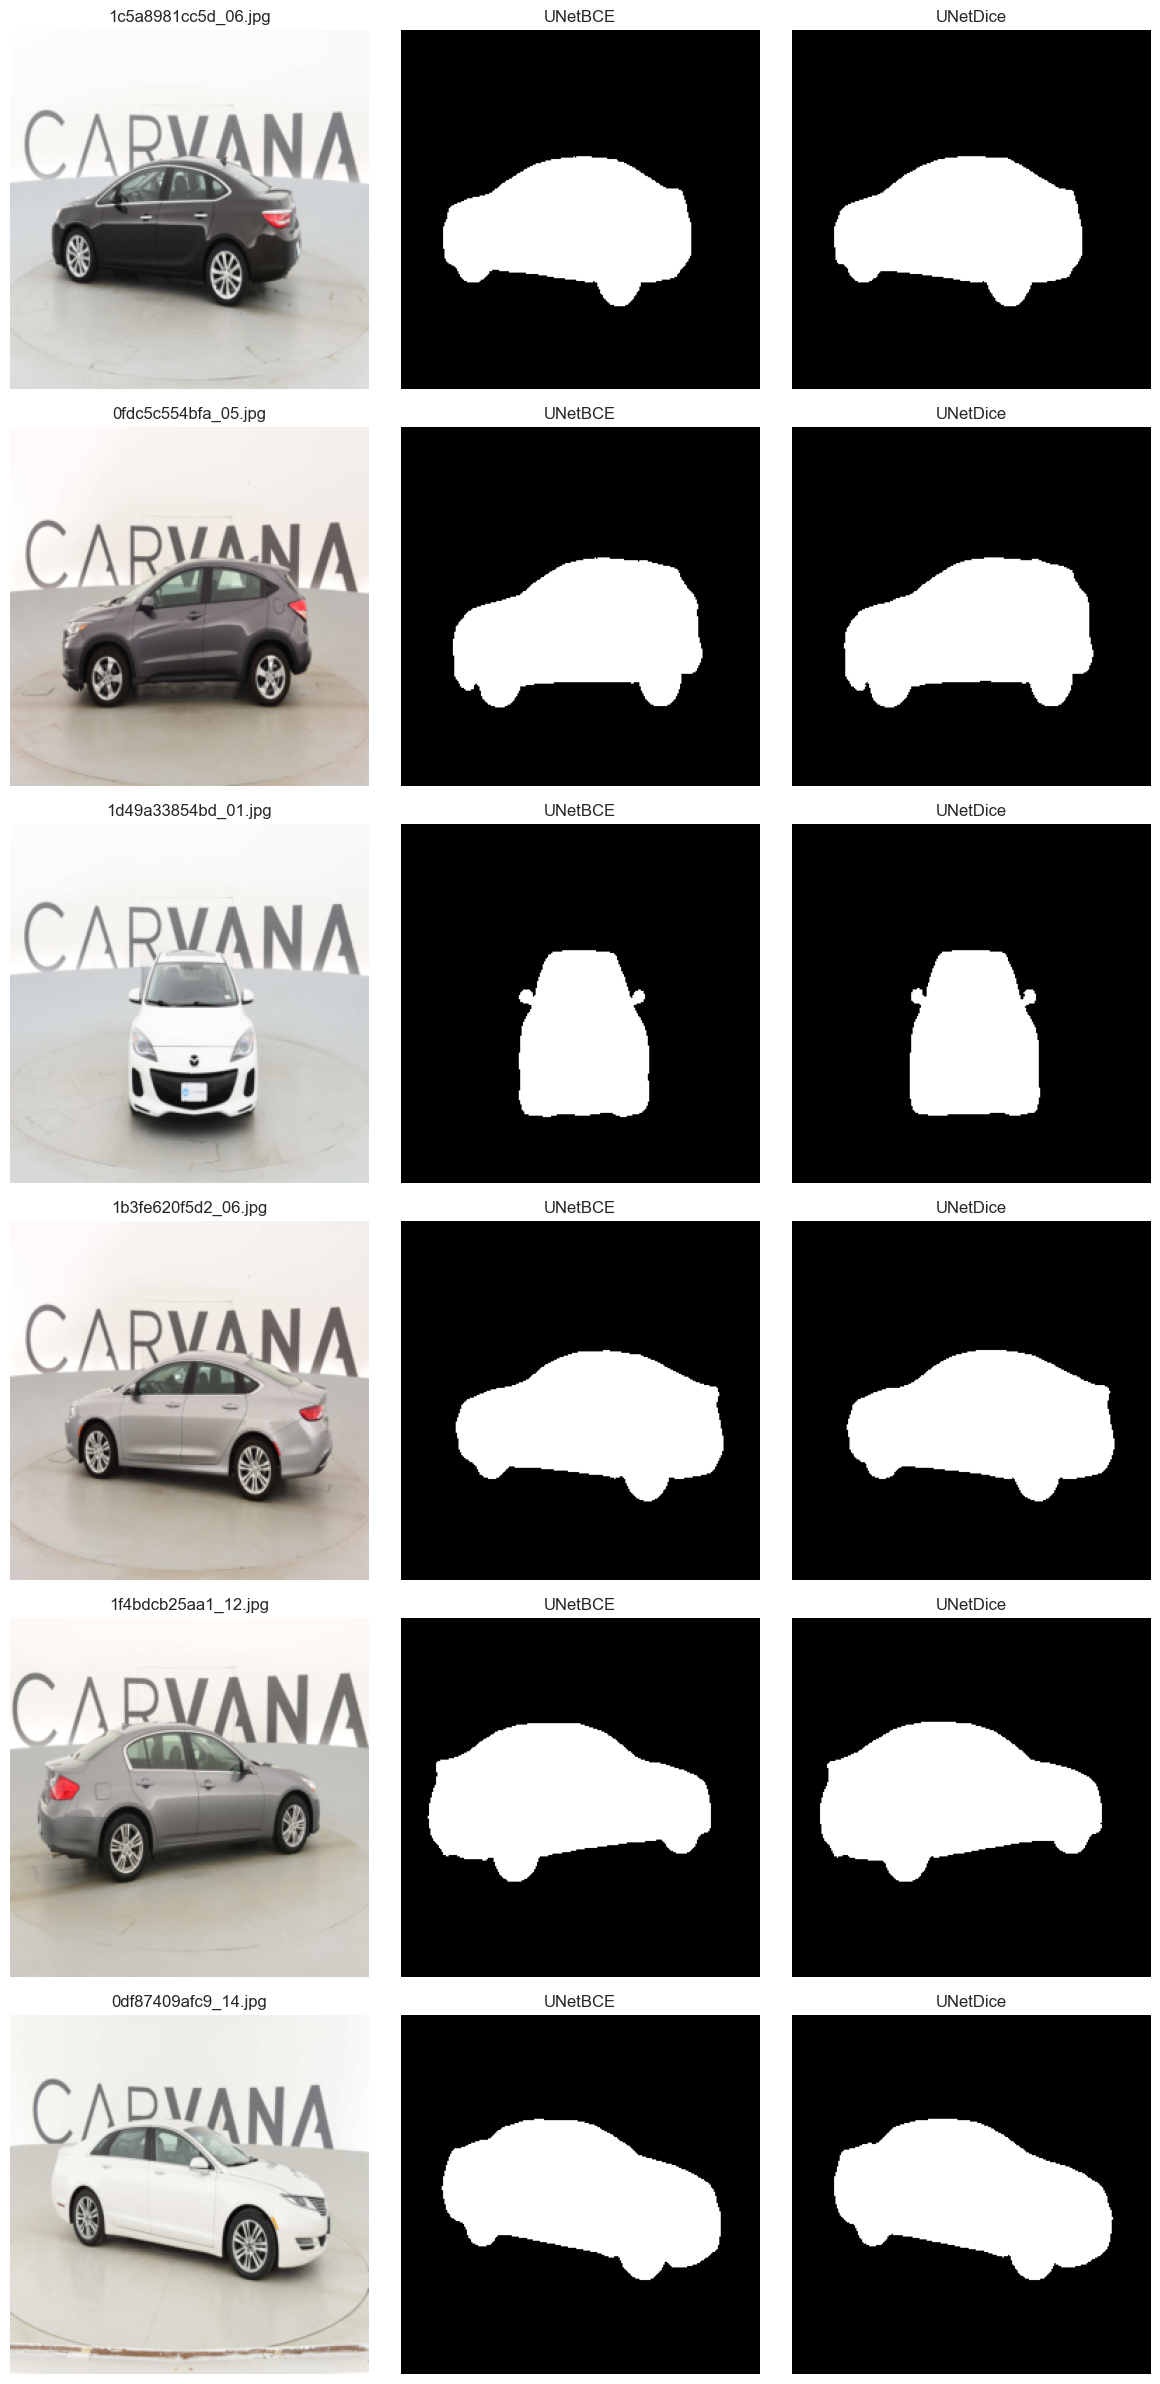

In [ ]:
def show_test_predictions_double(model1, model2, model1_name, model2_name, images_path, image_names, image_size, n_samples=6):
    model1.eval()
    model2.eval()

    _, axes = plt.subplots(nrows=n_samples, ncols=3, figsize=(12, n_samples * 4))
    if n_samples == 1:
        axes = axes[None, :]

    for i, image_name in enumerate(random.sample(image_names, n_samples)):
        image_path = os.path.join(images_path, image_name)
        image = Image.open(image_path).convert("RGB")
        image = TF.resize(image, image_size, interpolation=TF.InterpolationMode.BILINEAR)
        image_tensor = TF.to_tensor(image).unsqueeze(0)

        with torch.no_grad():
            pred1 = torch.sigmoid(model1(image_tensor))
            pred2 = torch.sigmoid(model2(image_tensor))

        pred1 = (pred1 > 0.5).float().cpu().squeeze()
        pred2 = (pred2 > 0.5).float().cpu().squeeze()

        axes[i, 0].imshow(image)
        axes[i, 0].set_title(image_name)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(pred1, cmap="gray")
        axes[i, 1].set_title(model1_name)
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred2, cmap="gray")
        axes[i, 2].set_title(model2_name)
        axes[i, 2].axis("off")

    plt.tight_layout()


show_test_predictions_double(
    model1=model_bce, model2=model_dice, model1_name=model_name_bce, model2_name=model_name_dice,
    images_path=test_path, image_names=test_images, image_size=image_size,
)

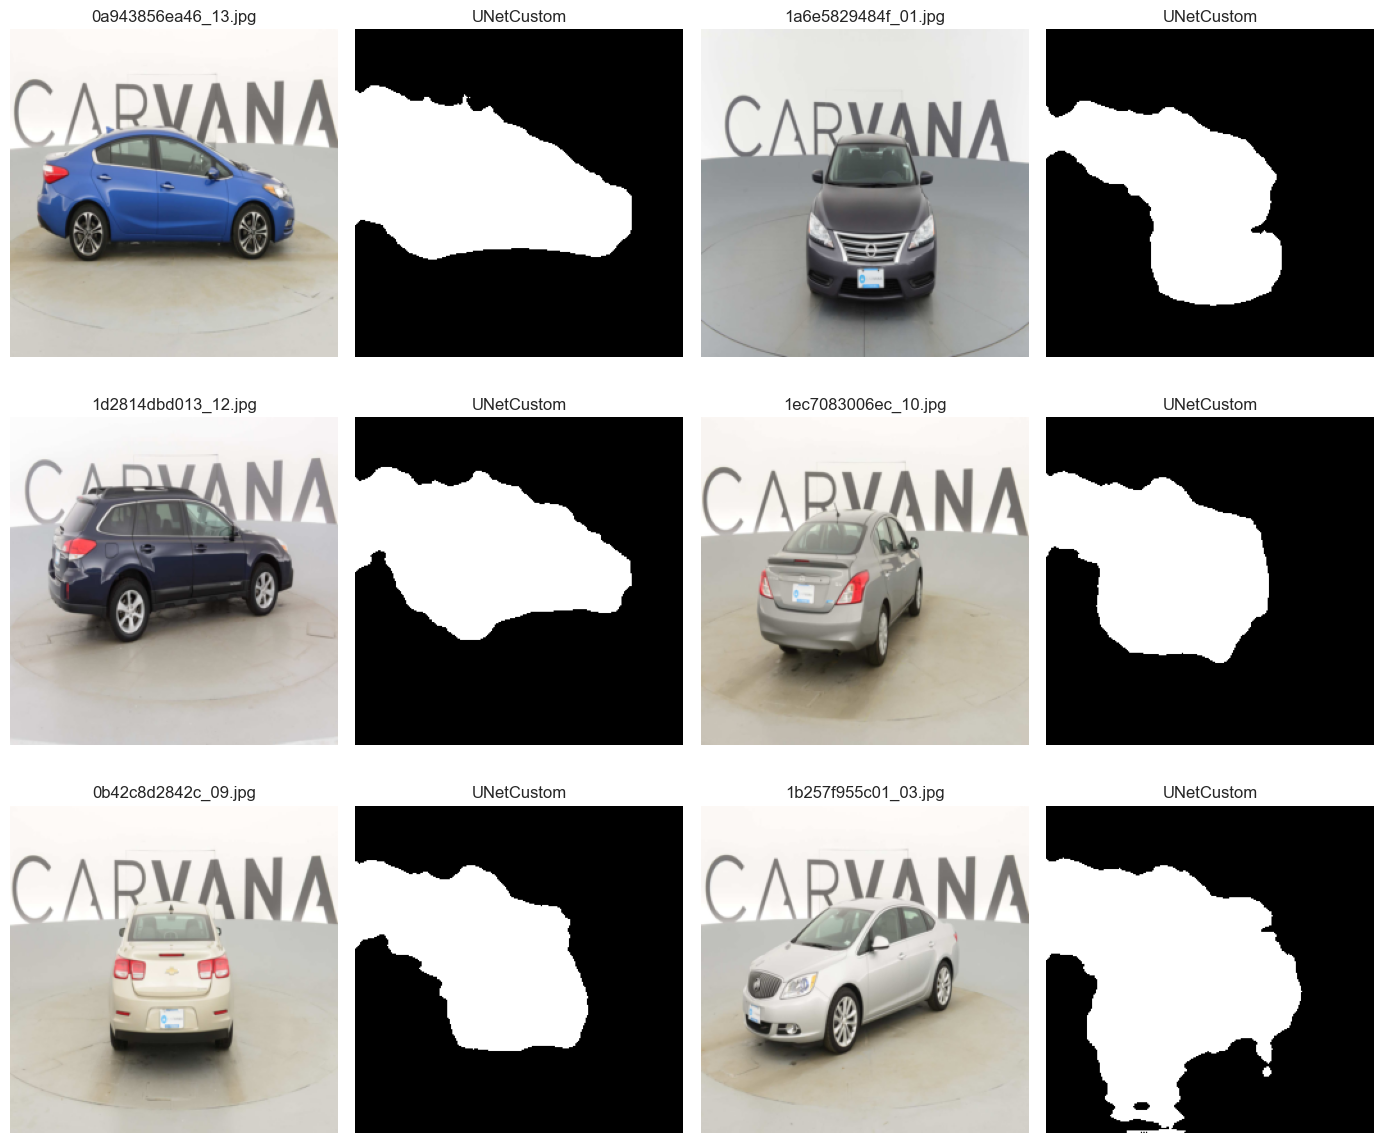

In [ ]:
def show_test_predictions_single(model, model_name, images_path, image_names, image_size, n_samples=6):
    model.eval()

    n_rows = n_samples // 2
    _, axes = plt.subplots(nrows=n_rows, ncols=4, figsize=(14, n_rows * 4))
    if n_samples == 1:
        axes = axes[None, :]

    for i, image_name in enumerate(random.sample(image_names, n_samples)):
        row = i // 2
        col = (i % 2) * 2

        image_path = os.path.join(images_path, image_name)
        image = Image.open(image_path).convert("RGB")
        image = TF.resize(image, image_size, interpolation=TF.InterpolationMode.BILINEAR)
        image_tensor = TF.to_tensor(image).unsqueeze(0)

        with torch.no_grad():
            pred = torch.sigmoid(model(image_tensor))
        pred = (pred > 0.5).float().cpu().squeeze()

        axes[row, col].imshow(image)
        axes[row, col].set_title(image_name)
        axes[row, col].axis("off")

        axes[row, col + 1].imshow(pred, cmap="gray", vmin=0, vmax=1)
        axes[row, col + 1].set_title(model_name)
        axes[row, col + 1].axis("off")

    plt.tight_layout()


show_test_predictions_single(
    model=model_custom, model_name=model_name_custom,
    images_path=test_path, image_names=test_images, image_size=image_size,
)